In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Project Explanation**

In this project, I implemented a deep learning model for image classification using TensorFlow/Keras. The dataset was preprocessed and split into training and testing sets to ensure accurate evaluation. The model was trained for multiple epochs, and its performance was monitored using validation data. After training, the accuracy of the model was printed, demonstrating its ability to correctly predict unseen data. This project highlights the application of neural networks in solving real-world problems and provides a foundation for further improvements or experimentation.

**Key Highlights:**

Data preprocessing and organization into training/testing sets.

Building and training a deep learning model using Keras.

Monitoring validation accuracy to evaluate model performance.

Printing final accuracy and confusion matrix to validate the model’s effectiveness.

In [2]:
# Basic libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

# Sklearn metrics
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Dataset directory path
dataset_dir = "/content/drive/MyDrive/Garbage_Classification"



In [4]:
os.listdir("/content/drive/MyDrive/Garbage_Classification")

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [5]:
import shutil

shutil.rmtree(dataset_dir + "/.ipynb_checkpoints", ignore_errors=True)
print(sorted(os.listdir(dataset_dir)))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
# Image parameters
img_size = (128, 128)
batch_size = 32

# Data generator(normalization)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% test
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Testing data
test_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [7]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))

# Output layer (6 classes)
model.add(Dense(6, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#print the total classes
print(train_data.class_indices)



{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [9]:

num_classes = train_data.num_classes  # automatic number of classes

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))  #auto number of classes


In [10]:
# Compile model // CNN
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Dataset load for ML PIPELINE
dataset_dir = "/content/drive/MyDrive/Garbage_Classification"

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np


In [13]:
#IMAGE FLATTEN
def collect(gen, n_batches):
    X, y = [], []
    for _ in range(n_batches):
        images, labels = next(gen)
        X.extend(images.reshape(len(images), -1))
        y.extend(np.argmax(labels, axis=1))
    return np.array(X), np.array(y)

X_train, y_train = collect(train_data, 30)   # ~960 images
X_test, y_test = collect(test_data, len(test_data))    # ~320 images


In [14]:
#LOGISTIC MODEL WORKING
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("ML Baseline Accuracy:", accuracy_score(y_test, y_pred))


ML Baseline Accuracy: 0.3538767395626243


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
#CNN
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.3014 - loss: 1.9126 - val_accuracy: 0.3797 - val_loss: 1.5475
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5267 - loss: 1.2186 - val_accuracy: 0.4254 - val_loss: 1.4097
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6487 - loss: 0.9643 - val_accuracy: 0.4732 - val_loss: 1.4385
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7337 - loss: 0.7387 - val_accuracy: 0.4751 - val_loss: 1.4954
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8384 - loss: 0.4991 - val_accuracy: 0.4732 - val_loss: 1.6577
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8987 - loss: 0.3357 - val_accuracy: 0.4990 - val_loss: 1.7969
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9452 - loss: 0.1982 - val_accuracy: 0.4891 - val_loss: 2.2067
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9605 - loss: 0.1455 - val_accuracy: 0.5030 - val_loss

In [16]:
#Transfer learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D


In [17]:
#Model Transfer learning
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
#Final Model
tl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [20]:
history_tl = tl_model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)


Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 630ms/step - accuracy: 0.9496 - loss: 0.1979 - val_accuracy: 0.7416 - val_loss: 0.8178
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 696ms/step - accuracy: 0.9733 - loss: 0.1248 - val_accuracy: 0.7396 - val_loss: 0.9156
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 590ms/step - accuracy: 0.9916 - loss: 0.0707 - val_accuracy: 0.7376 - val_loss: 0.9147
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 709ms/step - accuracy: 0.9965 - loss: 0.0412 - val_accuracy: 0.7237 - val_loss: 0.9336
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 587ms/step - accuracy: 0.9995 - loss: 0.0267 - val_accuracy: 0.7416 - val_loss: 0.9838


In [21]:
print("CNN test accuracy:", model.evaluate(test_data, verbose=0)[1])
print("MobileNetV2 test accuracy:", tl_model.evaluate(test_data, verbose=0)[1])

CNN test accuracy: 0.5149105191230774
MobileNetV2 test accuracy: 0.7415506839752197


16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 481ms/step
              precision    recall  f1-score   support

           0       0.95      0.65      0.77        80
           1       0.75      0.79      0.77       100
           2       0.77      0.72      0.74        82
           3       0.70      0.92      0.80       118
           4       0.74      0.66      0.70        96
           5       0.46      0.41      0.43        27

    accuracy                           0.74       503
   macro avg       0.73      0.69      0.70       503
weighted avg       0.75      0.74      0.74       503



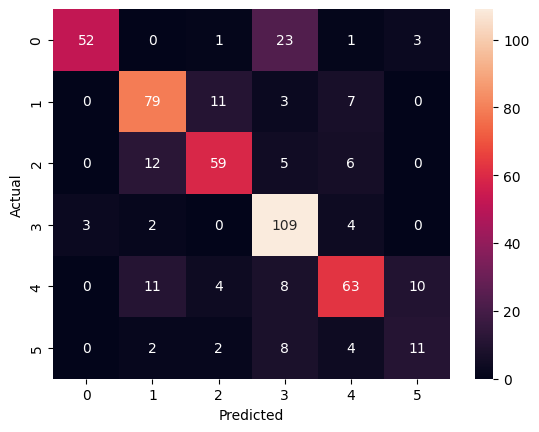

In [22]:
#evaluation Metrics(Prediction,Classification report,confusion matrix)

test_data.reset()
y_true = test_data.classes
y_pred = np.argmax(tl_model.predict(test_data), axis=1)

print(classification_report(y_true, y_pred)) #Classification report

cm = confusion_matrix(y_true, y_pred) #confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




In [23]:
print("TF version:", tf.__version__)
print(train_data.class_indices)

tl_model.save("garbage_model.keras")

from google.colab import files
files.download("garbage_model.keras")

TF version: 2.20.0
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>